In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/asthma-disease-prediction/processed-data.csv


small note on the Asthma dataset, you have to merge the severity type of the asthma (None, Mild and Severe) into one column for the final prediction.




In [2]:
df = pd.read_csv("/kaggle/input/asthma-disease-prediction/processed-data.csv")

In [3]:
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Severity_Mild,Severity_Moderate,Severity_None
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0


In [4]:
df.columns

Index(['Tiredness', 'Dry-Cough', 'Difficulty-in-Breathing', 'Sore-Throat',
       'None_Sympton', 'Pains', 'Nasal-Congestion', 'Runny-Nose',
       'None_Experiencing', 'Age_0-9', 'Age_10-19', 'Age_20-24', 'Age_25-59',
       'Age_60+', 'Gender_Female', 'Gender_Male', 'Severity_Mild',
       'Severity_Moderate', 'Severity_None'],
      dtype='object')

In [5]:
df.shape

(316800, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316800 entries, 0 to 316799
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Tiredness                316800 non-null  int64
 1   Dry-Cough                316800 non-null  int64
 2   Difficulty-in-Breathing  316800 non-null  int64
 3   Sore-Throat              316800 non-null  int64
 4   None_Sympton             316800 non-null  int64
 5   Pains                    316800 non-null  int64
 6   Nasal-Congestion         316800 non-null  int64
 7   Runny-Nose               316800 non-null  int64
 8   None_Experiencing        316800 non-null  int64
 9   Age_0-9                  316800 non-null  int64
 10  Age_10-19                316800 non-null  int64
 11  Age_20-24                316800 non-null  int64
 12  Age_25-59                316800 non-null  int64
 13  Age_60+                  316800 non-null  int64
 14  Gender_Female            316800 non-

In [7]:
df.isna().sum()

Tiredness                  0
Dry-Cough                  0
Difficulty-in-Breathing    0
Sore-Throat                0
None_Sympton               0
Pains                      0
Nasal-Congestion           0
Runny-Nose                 0
None_Experiencing          0
Age_0-9                    0
Age_10-19                  0
Age_20-24                  0
Age_25-59                  0
Age_60+                    0
Gender_Female              0
Gender_Male                0
Severity_Mild              0
Severity_Moderate          0
Severity_None              0
dtype: int64

**All data are not null**

In [8]:
#merged severity columns
df["Target"] = df.apply(lambda x : 1 if x["Severity_Mild"] else 2 if x["Severity_Moderate"] else 3 if x["Severity_None"] else 4,axis=1 )

In [9]:
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Severity_Mild,Severity_Moderate,Severity_None,Target
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0,2
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0,2


In [10]:
#drop severity type of the asthma (None, Mild and Severe
df.drop(columns="Severity_Mild", inplace=True)
df.drop(columns="Severity_Moderate", inplace=True)
df.drop(columns="Severity_None", inplace=True)

In [11]:
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Target
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,2
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,2


In [12]:
df.rename?

In [13]:
df["Label"] = df["Target"]

In [14]:
df = df.drop(columns=["Target"])

In [15]:
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Label
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,2
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,2


<Axes: xlabel='Label'>

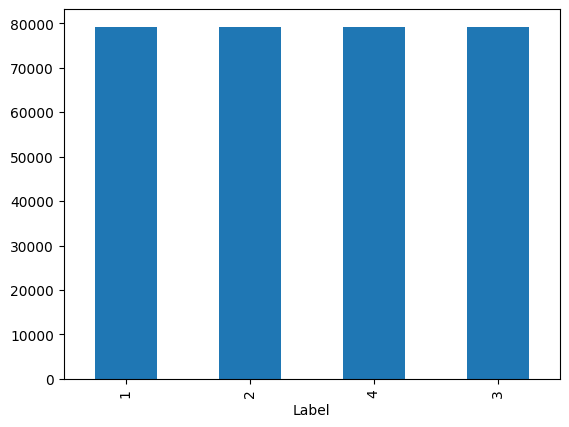

In [16]:
df.Label.value_counts().plot(kind="bar")

In [17]:
df.Label.value_counts().reset_index()


,Label,count
0,1,79200
1,2,79200
2,4,79200
3,3,79200


<Axes: xlabel='Label', ylabel='Difficulty-in-Breathing'>

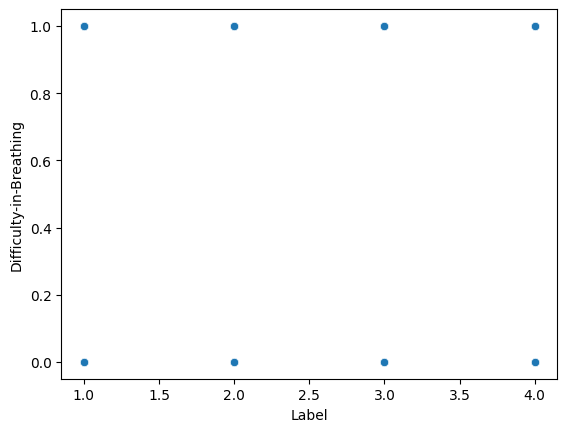

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns 
sns.scatterplot(df, x="Label", y="Difficulty-in-Breathing")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316800 entries, 0 to 316799
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Tiredness                316800 non-null  int64
 1   Dry-Cough                316800 non-null  int64
 2   Difficulty-in-Breathing  316800 non-null  int64
 3   Sore-Throat              316800 non-null  int64
 4   None_Sympton             316800 non-null  int64
 5   Pains                    316800 non-null  int64
 6   Nasal-Congestion         316800 non-null  int64
 7   Runny-Nose               316800 non-null  int64
 8   None_Experiencing        316800 non-null  int64
 9   Age_0-9                  316800 non-null  int64
 10  Age_10-19                316800 non-null  int64
 11  Age_20-24                316800 non-null  int64
 12  Age_25-59                316800 non-null  int64
 13  Age_60+                  316800 non-null  int64
 14  Gender_Female            316800 non-

<Axes: >

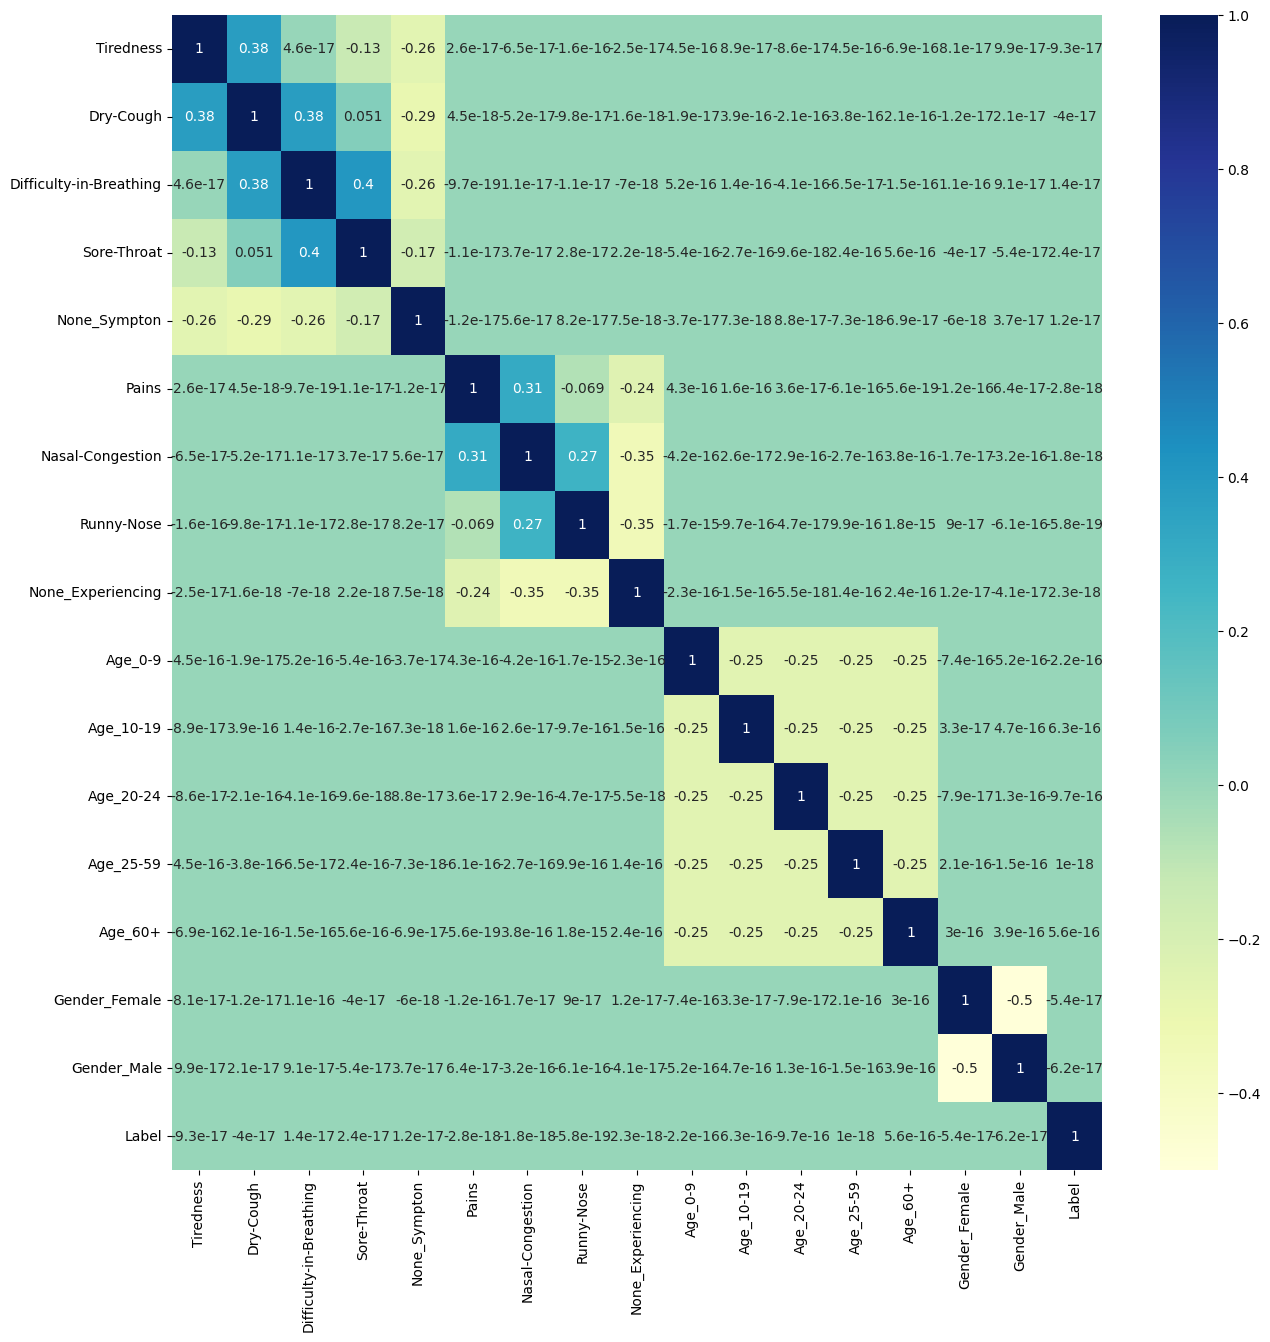

In [20]:
plt.figure(figsize=(15,15))

sns.heatmap(df.corr(), cmap='YlGnBu', annot=True)

<Axes: xlabel='Label', ylabel='Difficulty-in-Breathing'>

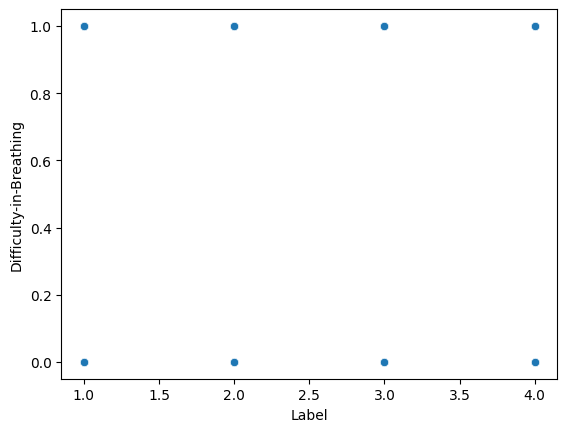

In [21]:
sns.scatterplot(df, x="Label", y="Difficulty-in-Breathing")

<Axes: xlabel='Label', ylabel='Nasal-Congestion'>

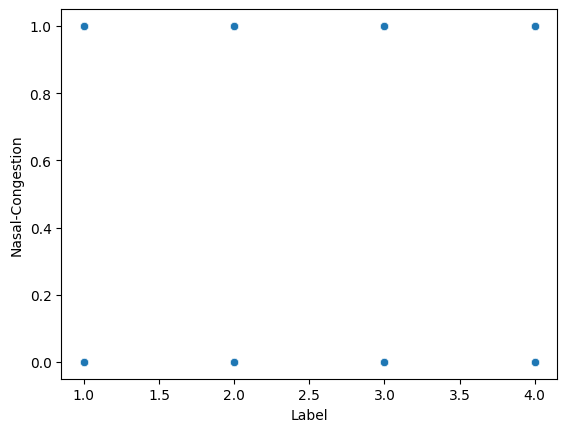

In [22]:
sns.scatterplot(df, x="Label", y="Nasal-Congestion")

<Axes: xlabel='Nasal-Congestion', ylabel='Difficulty-in-Breathing'>

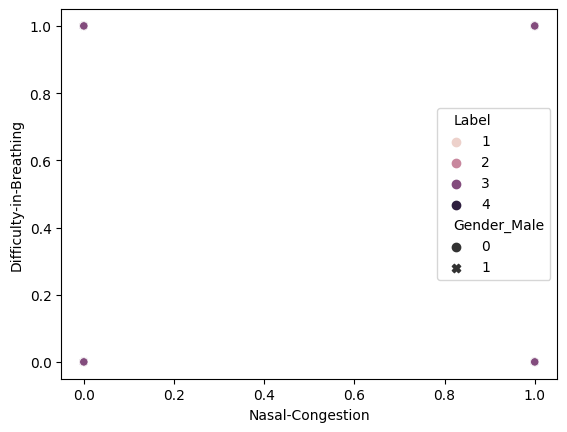

In [23]:
sns.scatterplot(df, x="Nasal-Congestion", y="Difficulty-in-Breathing", style="Gender_Male", hue="Label")

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='Difficulty-in-Breathing', ylabel='Count'>

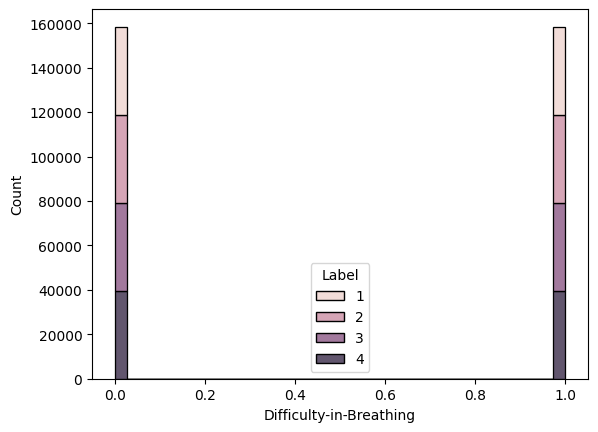

In [24]:
sns.histplot(df,x="Difficulty-in-Breathing",hue="Label",multiple="stack")

In [25]:
#sns.pairplot(df)

In [26]:
# function to print unique value counts in columns of a dataframe
def unique_col_counts(df, columns):
  for i in range(len(columns)):
    print(df[columns[i]].value_counts(),"\n")

# Display unique value counts in columns
columns = ['Tiredness',
 'Dry-Cough',
 'Difficulty-in-Breathing',
 'Sore-Throat',
 'None_Sympton',
 'Pains',
 'Nasal-Congestion',
 'Runny-Nose',
 'None_Experiencing',
 'Age_0-9',
 'Age_10-19',
 'Age_20-24',
 'Age_25-59',
 'Age_60+',
 'Gender_Female',
 'Gender_Male',
 'Label']
unique_col_counts(df, columns)

Tiredness
1    158400
0    158400
Name: count, dtype: int64 

Dry-Cough
1    178200
0    138600
Name: count, dtype: int64 

Difficulty-in-Breathing
1    158400
0    158400
Name: count, dtype: int64 

Sore-Throat
0    217800
1     99000
Name: count, dtype: int64 

None_Sympton
0    297000
1     19800
Name: count, dtype: int64 

Pains
0    201600
1    115200
Name: count, dtype: int64 

Nasal-Congestion
1    172800
0    144000
Name: count, dtype: int64 

Runny-Nose
1    172800
0    144000
Name: count, dtype: int64 

None_Experiencing
0    288000
1     28800
Name: count, dtype: int64 

Age_0-9
0    253440
1     63360
Name: count, dtype: int64 

Age_10-19
0    253440
1     63360
Name: count, dtype: int64 

Age_20-24
0    253440
1     63360
Name: count, dtype: int64 

Age_25-59
0    253440
1     63360
Name: count, dtype: int64 

Age_60+
0    253440
1     63360
Name: count, dtype: int64 

Gender_Female
0    211200
1    105600
Name: count, dtype: int64 

Gender_Male
0    211200
1    105600
Nam

# Train test split

In [27]:
X = df.drop(columns="Label")
y = df.Label

In [28]:
X

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316795,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0
316796,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0
316797,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0
316798,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0


In [29]:
y

0         1
1         1
2         1
3         2
4         2
         ..
316795    4
316796    4
316797    3
316798    3
316799    3
Name: Label, Length: 316800, dtype: int64

In [30]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

#for i in range(5):
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25)



In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)


In [32]:
print("hello")

hello


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           1       0.24      0.33      0.28     19800
           2       0.25      0.30      0.27     19800
           3       0.25      0.20      0.22     19800
           4       0.24      0.14      0.18     19800

    accuracy                           0.24     79200
   macro avg       0.24      0.24      0.24     79200
weighted avg       0.24      0.24      0.24     79200

              precision    recall  f1-score   support

           1       0.24      0.31      0.27     19800
           2       0.24      0.19      0.21     19800
           3       0.24      0.24      0.24     19800
           4       0.24      0.22      0.23     19800

    accuracy                           0.24     79200
   macro avg       0.24      0.24      0.24     79200
weighted avg       0.24      0.24      0.24     79200

              precision    recall  f1-score   support

           1       0.19      0.23      0.21     19800
           2       0.

# Feature engineering

In [34]:
from sklearn.preprocessing import PolynomialFeatures

#PolynomialFeatures? allow us to see the documentation

poly_3 = PolynomialFeatures(5)

X_train_poly = poly_3.fit_transform(X_train)


In [ ]:
X_train.shape

In [ ]:
X_train_poly.shape

In [ ]:
X_test_poly = poly_3.fit_transform(X_test)

In [ ]:
X_test.shape

In [ ]:
X_test_poly.shape

In [ ]:
lr_poly = LogisticRegression()
knn_poly = KNeighborsClassifier()
dt_poly = DecisionTreeClassifier()
rf_poly = RandomForestClassifier()

lr_poly.fit(X_train_poly, y_train)
knn_poly.fit(X_train_poly, y_train)
dt_poly.fit(X_train_poly, y_train)
rf_poly.fit(X_train_poly, y_train)

y_pred_lr_poly = lr_poly.predict(X_test_poly)
y_pred_knn_poly = knn_poly.predict(X_test_poly)
y_pred_dt_poly = dt_poly.predict(X_test_poly)
y_pred_rf_poly = rf_poly.predict(X_test_poly)

In [ ]:
print(classification_report(y_test, y_pred_knn_poly))

print(classification_report(y_test, y_pred_lr_poly))

print(classification_report(y_test, y_pred_dt_poly))

print(classification_report(y_test, y_pred_rf_poly))